In [ ]:
!pip install HiggsML
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 3.3 MB/s eta 0:00:00


In [ ]:
# First we import librairies
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from HiggsML.datasets import download_dataset
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
import optuna

# BDT Class

In [ ]:
# Here we create our BDT
class BoostedDecisionTree:
    def __init__(
        self,
        n_estimators=1500,
        max_depth=6,
        learning_rate=0.02,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=6,
        gamma=0,
        tree_method="hist",
        random_state=31415,
        early_stopping_rounds=25,
        scale_factor=1.0,
    ):

        self.scale_factor = scale_factor

        # Instancing model
        self.model = XGBClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            min_child_weight=min_child_weight,
            gamma=gamma,
            tree_method=tree_method,
            random_state=random_state,
            early_stopping_rounds=early_stopping_rounds,
        )

    def fit(self, train_data, labels, weights=None):
        # Counting background and signal events
        sum_w_background = np.sum(weights[labels == 0])
        sum_w_signal = np.sum(weights[labels == 1])

        # Dynamicly computing the ratio
        ratio = (sum_w_background / sum_w_signal) * self.scale_factor
        self.model.set_params(scale_pos_weight=ratio)
        print(f"[INFO] scale_pos_weight configuré à {ratio:.2f}")

        # Getting training and validation data
        X_tr, X_val, y_tr, y_val, w_tr, w_val = train_test_split(
            train_data, labels, weights, test_size=0.2, random_state=42, stratify=labels
        )

        # Training model
        self.model.fit(
            X_tr,
            y_tr,
            sample_weight=w_tr,
            eval_set=[(X_val, y_val)],
            sample_weight_eval_set=[w_val],
            verbose=False,
        )

    def predict(self, test_data):
        return self.model.predict_proba(test_data)[:, 1]

# Load Data

In [ ]:
data = download_dataset("blackSwan_data")
data.load_train_set()
data_set = data.get_train_set()

train_data = data_set.drop(columns=["labels", "weights", "detailed_labels"])
labels = data_set["labels"]
weights = data_set["weights"]

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    train_data, labels, weights, test_size=0.3, random_state=42, stratify=labels
)

# Hyperparameters optimization

[I 2026-06-04 07:29:35,472] A new study created in memory with name: no-name-736ab660-2d1d-4922-a820-c1d733d24c25



Début de l'optimisation Bayésienne avec Optuna (2 itérations)...
[INFO] scale_pos_weight configuré à 155.53


[I 2026-06-04 07:34:58,532] Trial 0 finished with value: 0.8842257145912811 and parameters: {'max_depth': 11, 'learning_rate': 0.014236752484543203, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 6}. Best is trial 0 with value: 0.8842257145912811.


Itération 1/2 | AUC Validation: 0.8842 | Meilleur AUC historique: 0.8842
[INFO] scale_pos_weight configuré à 155.53


[I 2026-06-04 07:36:05,682] Trial 1 finished with value: 0.8826245307238729 and parameters: {'max_depth': 7, 'learning_rate': 0.0931787969254261, 'subsample': 0.6, 'colsample_bytree': 1.0, 'min_child_weight': 9}. Best is trial 0 with value: 0.8842257145912811.


Itération 2/2 | AUC Validation: 0.8826 | Meilleur AUC historique: 0.8842

FIN DE L'OPTIMISATION BAYÉSIENNE
Meilleur score AUC de validation mémorisé : 0.88423
Meilleurs hyperparamètres correspondants :
  - max_depth: 11
  - learning_rate: 0.014236752484543203
  - subsample: 0.8
  - colsample_bytree: 0.8
  - min_child_weight: 6


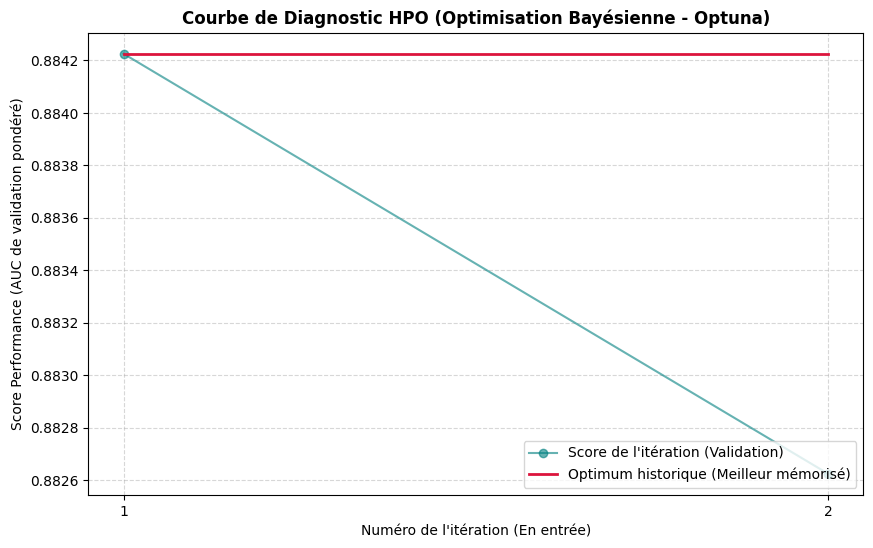

In [ ]:
X_train, X_val, y_train, y_val, w_train, w_val = train_test_split(
    train_data, labels, weights, test_size=0.2, random_state=31415
)


# Objective function for Optuna optimization loop
def objective(trial):
    # Hyperparameter search space boundaries
    max_depth = trial.suggest_int("max_depth", 3, 13, step=2)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.1, log=True)
    subsample = trial.suggest_float("subsample", 0.6, 1.0, step=0.2)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0, step=0.2)
    min_child_weight = trial.suggest_int("min_child_weight", 1, 10)

    bdt_hpo = BoostedDecisionTree(
        n_estimators=1000,  # Fixed (managed by early stopping)
        tree_method="hist",  # Fixed (for computing speed)
        # device='cuda',
        random_state=31415,  # Fixed (for reproducibility)
        early_stopping_rounds=15,  # Fixed (to prevent overfitting)
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        min_child_weight=min_child_weight,
    )

    # 1. On entraîne le modèle sur la base d'entraînement (X_train)
    bdt_hpo.fit(X_train, y_train, weights=w_train)

    # 2. On évalue et calcule l'AUC sur la base de validation (X_val)
    predictions = bdt_hpo.predict(X_val)
    score_auc = roc_auc_score(y_val, predictions, sample_weight=w_val)

    return score_auc


# Run Bayesian optimization
NB_ITERATIONS = 15
print(
    f"\nDébut de l'optimisation Bayésienne avec Optuna ({NB_ITERATIONS} itérations)..."
)

study = optuna.create_study(direction="maximize")

# Arrays to store results for the diagnostic curve
historique_scores = []
historique_meilleurs_scores = []

for i in range(1, NB_ITERATIONS + 1):
    study.optimize(objective, n_trials=1)

    dernier_trial = study.trials[-1]
    score_courant = dernier_trial.value
    meilleur_score_actuel = study.best_value

    historique_scores.append(score_courant)
    historique_meilleurs_scores.append(meilleur_score_actuel)

    print(
        f"Itération {i}/{NB_ITERATIONS} | AUC Validation: {score_courant:.4f} | Meilleur AUC historique: {meilleur_score_actuel:.4f}"
    )

# Terminal outputs
print("\n" + "=" * 50)
print("FIN DE L'OPTIMISATION BAYÉSIENNE")
print(f"Meilleur score AUC de validation mémorisé : {study.best_value:.5f}")
print("Meilleurs hyperparamètres correspondants :")
for param, valeur in study.best_params.items():
    print(f"  - {param}: {valeur}")
print("=" * 50)

# Plot HPO diagnostic curve
plt.figure(figsize=(10, 6))
plt.plot(
    range(1, NB_ITERATIONS + 1),
    historique_scores,
    marker="o",
    color="teal",
    alpha=0.6,
    label="Score de l'itération (Validation)",
)
plt.step(
    range(1, NB_ITERATIONS + 1),
    historique_meilleurs_scores,
    where="mid",
    color="crimson",
    linewidth=2,
    label="Optimum historique (Meilleur mémorisé)",
)

plt.title(
    "Courbe de Diagnostic HPO (Optimisation Bayésienne - Optuna)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Numéro de l'itération (En entrée)", fontsize=10)
plt.ylabel("Score Performance (AUC de validation pondéré)", fontsize=10)
plt.xticks(
    range(1, NB_ITERATIONS + 1, max(1, NB_ITERATIONS // 10))
)  # Ajustement automatique des graduations pour 100 itérations
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower right")

plt.show()

# Model evaluation
* AUC



In [ ]:
bdt = BoostedDecisionTree(
    max_depth=11,
    learning_rate=0.015619081519761545,
    subsample=0.8,
    colsample_bytree=1.0,
    min_child_weight=4,
)

bdt.fit(X_train, y_train, w_train)

predictions = bdt.predict(X_test)

auc = roc_auc_score(y_test, predictions, sample_weight=w_test)

print("AUC =", auc)

[INFO] scale_pos_weight configuré à 155.41
AUC = 0.8836514260310343


* ROC curve

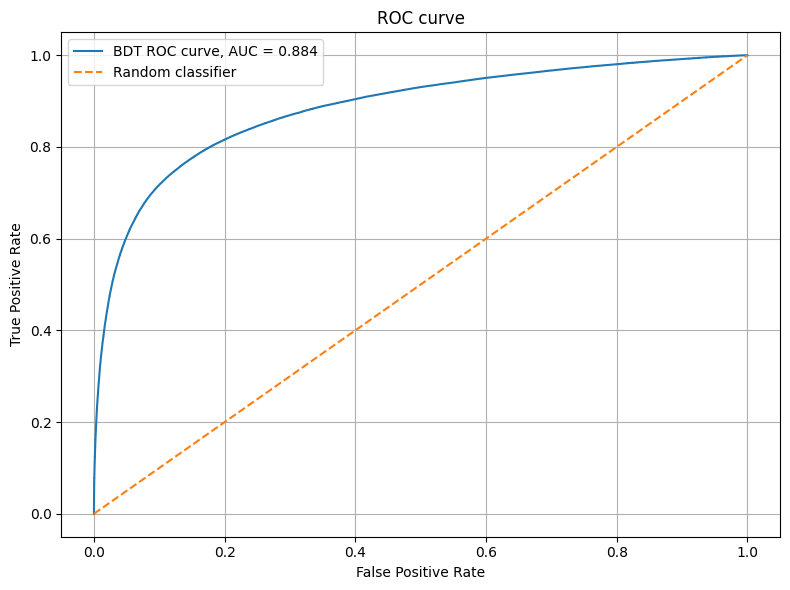

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, predictions, sample_weight=w_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"BDT ROC curve, AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

* significance curve

Best threshold: 0.949748743718593
Best Poisson significance: 3.6786541065437848


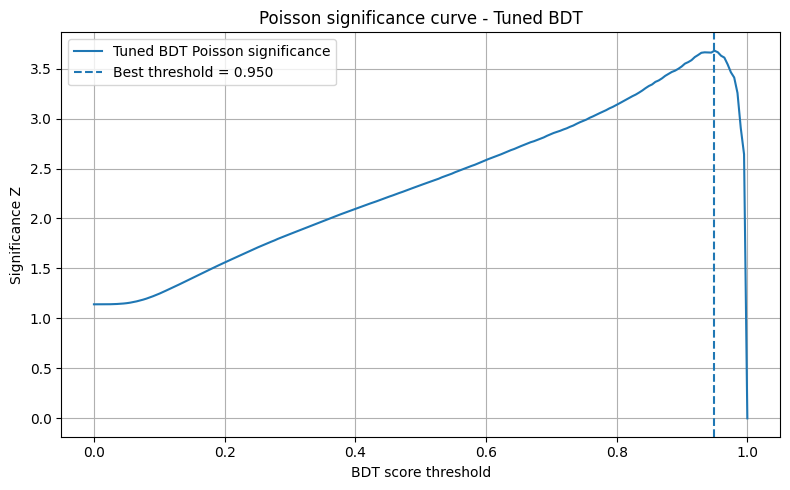

In [ ]:
thresholds = np.linspace(0, 1, 200)

significances = []
S_values = []
B_values = []

for threshold in thresholds:
    selected = predictions > threshold

    S = np.sum(w_test[(y_test == 1) & selected])
    B = np.sum(w_test[(y_test == 0) & selected])

    if S > 0 and B > 0:
        Z = np.sqrt(2 * ((S + B) * np.log(1 + S / B) - S))
    else:
        Z = 0

    significances.append(Z)
    S_values.append(S)
    B_values.append(B)

significances = np.array(significances)

best_index = np.argmax(significances)
best_threshold = thresholds[best_index]
best_significance = significances[best_index]

print("Best threshold:", best_threshold)
print("Best Poisson significance:", best_significance)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, significances, label="Tuned BDT Poisson significance")
plt.axvline(
    best_threshold, linestyle="--", label=f"Best threshold = {best_threshold:.3f}"
)

plt.xlabel("BDT score threshold")
plt.ylabel("Significance Z")
plt.title("Poisson significance curve - Tuned BDT")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

* signal vs background normalized score distribution

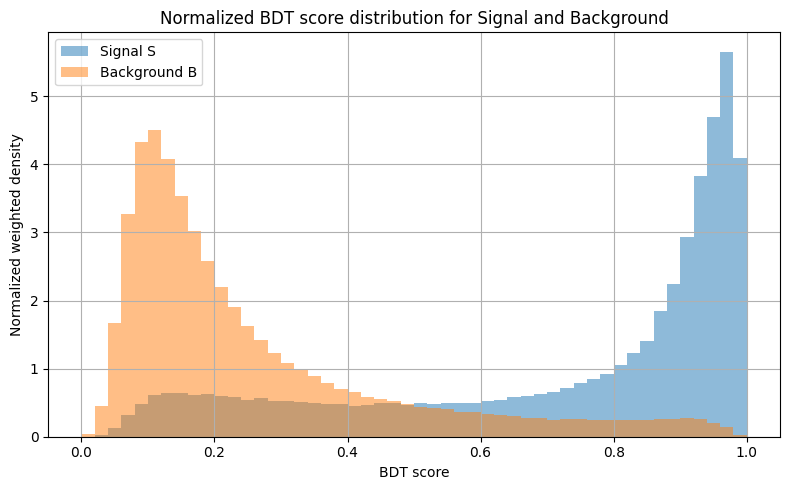

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    predictions[y_test == 1],
    bins=50,
    range=(0, 1),
    weights=w_test[y_test == 1],
    density=True,
    alpha=0.5,
    label="Signal S",
)

plt.hist(
    predictions[y_test == 0],
    bins=50,
    range=(0, 1),
    weights=w_test[y_test == 0],
    density=True,
    alpha=0.5,
    label="Background B",
)

plt.xlabel("BDT score")
plt.ylabel("Normalized weighted density")
plt.title("Normalized BDT score distribution for Signal and Background")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

* learning curve

Training with 10% of the training data...
[INFO] scale_pos_weight configuré à 155.41
Train AUC = 0.9035
Test AUC  = 0.8773

Training with 32% of the training data...
[INFO] scale_pos_weight configuré à 155.41
Train AUC = 0.8935
Test AUC  = 0.8808

Training with 55% of the training data...
[INFO] scale_pos_weight configuré à 155.41
Train AUC = 0.8910
Test AUC  = 0.8820

Training with 78% of the training data...
[INFO] scale_pos_weight configuré à 155.41
Train AUC = 0.8893
Test AUC  = 0.8825

Training with 100% of the training data...
[INFO] scale_pos_weight configuré à 155.41
Train AUC = 0.8881
Test AUC  = 0.8828



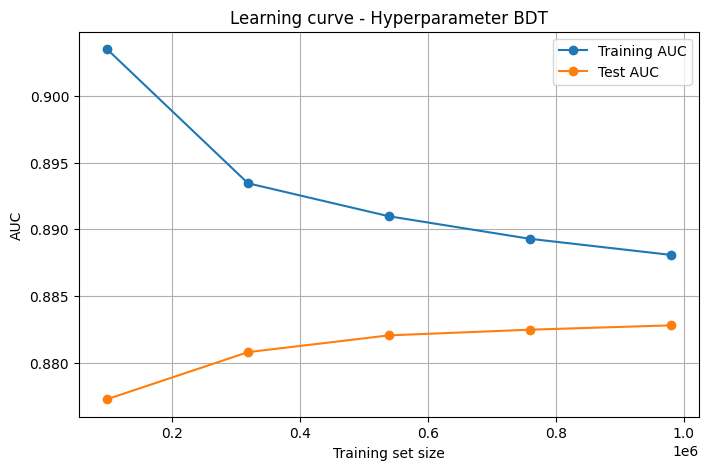

In [ ]:
train_fractions = np.linspace(0.1, 1.0, 5)

train_aucs = []
test_aucs = []
train_sizes = []

X_train_full = X_train.copy()
y_train_full = y_train.copy()
w_train_full = w_train.copy()

for frac in train_fractions:
    print(f"Training with {frac:.0%} of the training data...")

    if frac < 1.0:
        X_train, _, y_train, _, w_train, _ = train_test_split(
            X_train_full,
            y_train_full,
            w_train_full,
            train_size=frac,
            random_state=42,
            stratify=y_train_full,
        )
    else:
        X_train = X_train_full
        y_train = y_train_full
        w_train = w_train_full

    bdt = BoostedDecisionTree()

    bdt.fit(X_train, y_train, w_train)

    train_scores = bdt.predict(X_train)
    test_scores = bdt.predict(X_test)

    train_auc = roc_auc_score(y_train, train_scores, sample_weight=w_train)
    test_auc = roc_auc_score(y_test, test_scores, sample_weight=w_test)

    train_aucs.append(train_auc)
    test_aucs.append(test_auc)
    train_sizes.append(len(X_train))

    print(f"Train AUC = {train_auc:.4f}")
    print(f"Test AUC  = {test_auc:.4f}")
    print()

plt.figure(figsize=(8, 5))

plt.plot(train_sizes, train_aucs, "o-", label="Training AUC")
plt.plot(train_sizes, test_aucs, "o-", label="Test AUC")

plt.xlabel("Training set size")
plt.ylabel("AUC")
plt.title("Learning curve - Hyperparameter BDT")
plt.legend()
plt.grid()

plt.show()